In [86]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [87]:
df=pd.read_csv('Social_Network_Ads.csv')
df=df.iloc[:,2:]
df.index=range(1,len(df)+1)
df.head()

,Age,EstimatedSalary,Purchased
1,19,19000,0
2,35,20000,0
3,26,43000,0
4,27,57000,0
5,19,76000,0


In [88]:
from sklearn.model_selection import train_test_split
X=df[['Age','EstimatedSalary']]
y=df['Purchased']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)
print(X_train.shape)
print(X_test.shape)

(280, 2)
(120, 2)


In [89]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [90]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [91]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [92]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [93]:
np.round(X_train_scaled.describe())

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-2.0
25%,-1.0,-1.0
50%,-0.0,0.0
75%,1.0,1.0
max,2.0,2.0


Text(0.5, 1.0, 'After_Scaling')

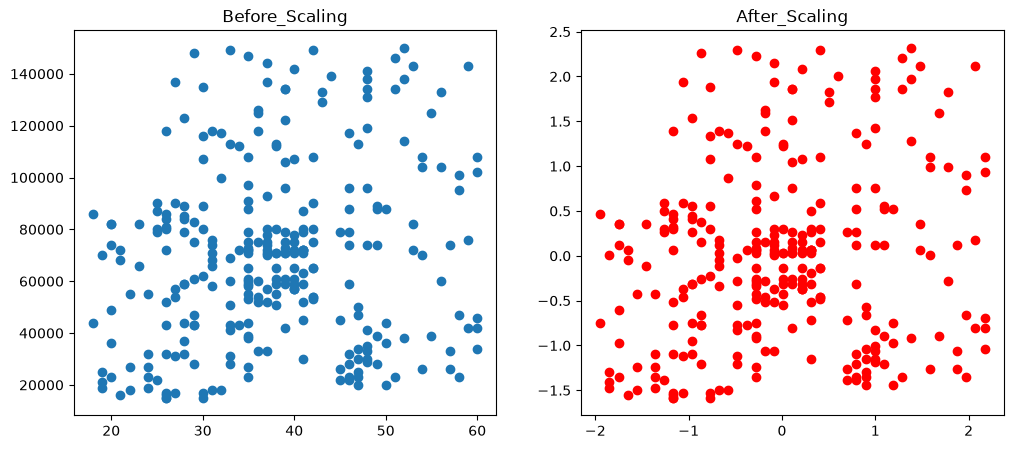

In [94]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('Before_Scaling')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('After_Scaling')


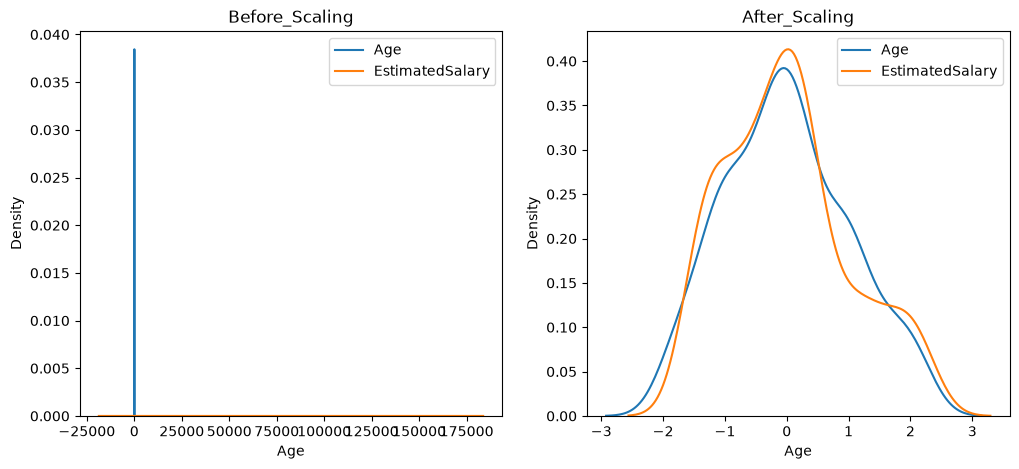

In [95]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
sns.kdeplot(X_train['Age'],ax=ax1,label='Age')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1,label='EstimatedSalary')
ax1.set_title('Before_Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2,label='Age')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2,label='EstimatedSalary')
ax2.set_title('After_Scaling')
ax1.legend()
ax2.legend()

Text(0.5, 1.0, 'After_Scaling')

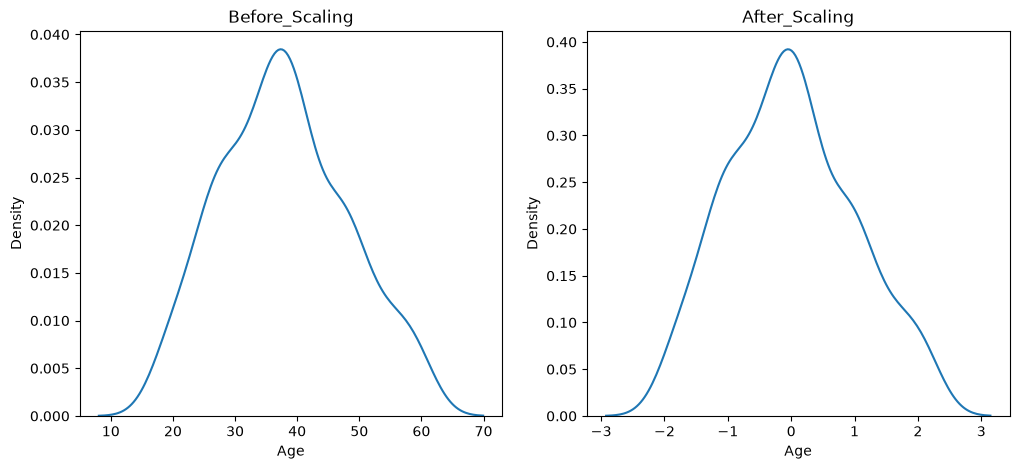

In [96]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
sns.kdeplot(X_train['Age'],ax=ax1)

ax1.set_title('Before_Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)

ax2.set_title('After_Scaling')


Text(0.5, 1.0, 'After_Scaling')

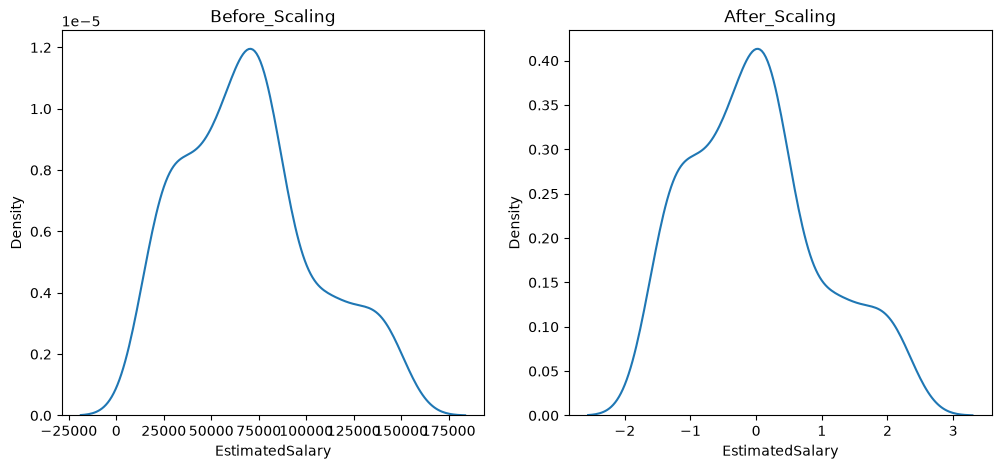

In [97]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
ax1.set_title('Before_Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
ax2.set_title('After_Scaling')


In [98]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()

lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [99]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [100]:
from sklearn.metrics import accuracy_score

print(f"Actual:{accuracy_score(y_test,y_pred)}")
print(f"Scaled:{accuracy_score(y_test,y_pred_scaled)}")

Actual:0.875
Scaled:0.8666666666666667
